## Logistic Regression Challenge

I want to see if I predict the bank loan approvals based on the backloan.csv dataset pulled from Kaggle.

https://www.kaggle.com/datasets/vikramamin/bank-loan-approval-lr-dt-rf-and-auc/data

In [2]:
import pandas as pd

loan_data = pd.read_csv("./bankloan.csv")
loan_data.head()

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


First, I want to encode the features and label if needed (the dataset has only numeric values).

Then, I want to see if any of the features provide a clear distinction between the two classes (Approved and Not Approved). According to the dataset, 1 = approved and 0 = not approved.

/var/folders/58/zswvmx6j7bvgh2rb6l6v3bqm0000gn/T/ipykernel_78193/2885407097.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.swarmplot(x="Personal.Loan", y="CCAvg", data=loan_data, palette=palette)
/Users/don/Desktop/machine-learning/ml-for-beginners/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 71.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='Personal.Loan', ylabel='CCAvg'>

/Users/don/Desktop/machine-learning/ml-for-beginners/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 80.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


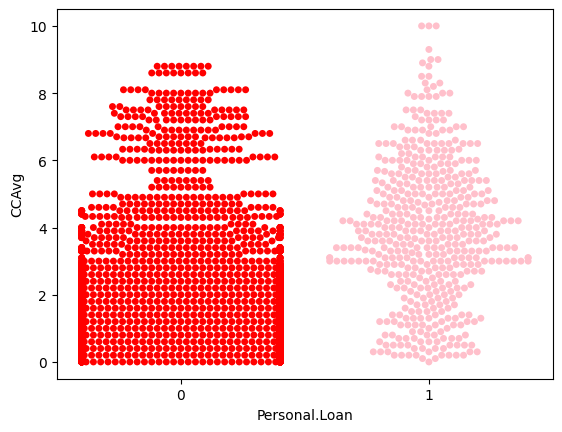

In [ ]:
from sklearn.preprocessing import OrdinalEncoder 
import seaborn as sb




palette = {
    '0': 'red',
    '1': 'pink'
}

# sb.swarmplot(x="Personal.Loan", y="Age", data=loan_data, palette=palette)
# sb.swarmplot(x="Personal.Loan", y="Experience", data=loan_data, palette=palette)
# sb.swarmplot(x="Personal.Loan", y="CCAvg", data=loan_data, palette=palette)

In [52]:
features = [
    "Income", 
    "CCAvg",
    "Age", 
    "Experience"
]
features = loan_data.loc[:, features]
label = loan_data.loc[:, ["Personal.Loan"]]

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


x_train, x_test, y_train, y_test = train_test_split(
    features,
    label,
    test_size=0.3
)

model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)



print(confusion_matrix(y_test, y_pred))

classification_report(y_test, y_pred, output_dict=True)



[[1324   34]
 [  92   50]]


/Users/don/Desktop/machine-learning/ml-for-beginners/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


{'0': {'precision': 0.9350282485875706,
  'recall': 0.9749631811487481,
  'f1-score': 0.9545782263878875,
  'support': 1358.0},
 '1': {'precision': 0.5952380952380952,
  'recall': 0.352112676056338,
  'f1-score': 0.4424778761061947,
  'support': 142.0},
 'accuracy': 0.916,
 'macro avg': {'precision': 0.7651331719128329,
  'recall': 0.6635379286025431,
  'f1-score': 0.6985280512470411,
  'support': 1500.0},
 'weighted avg': {'precision': 0.9028614474038205,
  'recall': 0.916,
  'f1-score': 0.9060993932278872,
  'support': 1500.0}}